# 03 · Our own win-probability model (step G1)

**Win probability (WP)** answers one question before every snap: *how likely is the team with the
ball to win this game?* It looks only at the situation: the score, the clock, down and distance,
field position, timeouts, who gets the ball after halftime, home field and the betting market's
pregame spread. Example: up 7 with two minutes left and the ball at midfield is a very high WP;
down 7 in the same spot is low.

The Decision Report Card (coming next) grades coaches' fourth-down and two-point calls by asking
WP *what would have happened* after each option, so it needs a WP model it can trust.

## Why not just use nflfastR's `wp`?

nflfastR's play-by-play already has `wp` and `vegas_wp`. But those models were fit on many
seasons, including the ones we want to grade, so they partly *know how those seasons ended*
(PROJECT_SPEC 6.3). Ours is trained **walk-forward**: to score season S it learns only from
seasons before S, like a model built in the summer before S. Its mistakes are honest
out-of-sample mistakes.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from twm.config import settings
from twm.modules.decisions import wp
from twm.modules.decisions import wp_report as wr
from twm.modules.decisions.wp_data import load_states

pl.Config.set_tbl_rows(25)
pl.Config.set_tbl_hide_dataframe_shape(True)
_ = pl.Config.set_tbl_hide_column_data_types(True)

## 1. The plays

One row per scrimmage play (runs, passes, punts, field goals, kneels, spikes) with a complete
situation before the snap. The label is simply: did the team with the ball win? Tie games are
left out (there is no winner).

In [2]:
states = load_states(settings().path("warehouse"), tuple(range(1999, 2026)))
print(f"{states.rows.height:,} plays 1999-2025")
print("rows dropped by each filter:", states.drops, f"({states.n_tie_games} tie games)")

1,009,826 plays 1999-2025
rows dropped by each filter: {'unplayed': 0, 'not_scrimmage': 267183, 'missing_state': 19, 'tie': 2600} (15 tie games)


In [3]:
cols = ["season", "qtr", "posteam", "score_differential", "game_seconds_remaining", "down",
        "ydstogo", "yardline_100", "posteam_spread", "receives_2h_kickoff", "posteam_wins"]
states.rows.filter(pl.col("game_id") == "2016_21_NE_ATL").select(cols).head(5)

season,qtr,posteam,score_differential,game_seconds_remaining,down,ydstogo,yardline_100,posteam_spread,receives_2h_kickoff,posteam_wins
2016,1,"""NE""",0,3600,1,10,75,3.0,0,1
2016,1,"""NE""",0,3595,2,10,75,3.0,0,1
2016,1,"""NE""",0,3566,3,1,66,3.0,0,1
2016,1,"""NE""",0,3527,4,1,66,3.0,0,1
2016,1,"""ATL""",0,3517,1,10,92,-3.0,1,0


## 2. Walk-forward folds

One model per test season 2006-2025. The first one learns from 1999-2005, the last from
1999-2024. Each picks its settings on the season just before the test season, then is refit on
every earlier season. The table shows what each fold chose and how long it took (one CPU thread,
so the result is identical on every run).

In [4]:
frame, summaries = wr.load_backtest(states)
pl.DataFrame([{"test season": s["test_season"], "training plays": s["n_train"],
               "trees": s["params"]["n_estimators"], "leaves": s["params"]["num_leaves"],
               "isotonic": s["calibration"].startswith("isotonic"), "seconds": s["seconds"]}
              for s in summaries])

test season,training plays,trees,leaves,isotonic,seconds
2006,255901,221,63,false,36.0
2007,292928,167,31,false,31.9
2008,329854,275,31,false,51.0
2009,366179,283,63,false,61.1
2010,403292,152,63,false,41.1
2011,440549,237,31,false,61.4
2012,478252,165,31,false,51.3
2013,516069,197,63,false,66.8
2014,554210,166,63,false,62.7
2015,591736,274,63,false,91.1


## 3. How good is it?

Two scores, both *lower is better*:
- **Brier score**: the average squared gap between the forecast and what happened (1 = win,
  0 = loss). Always saying 50% scores 0.25.
- **Log loss**: punishes confident misses hard (saying 99% and losing is very costly).

The ranges are 95% intervals from resampling whole seasons (a bad season for the model counts
as a whole).

In [5]:
pp = wr.per_play(frame)
pooled = pl.DataFrame(wr.metric_rows(pp, "pooled", "2006-2025"), schema=wr.SCHEMA, orient="row")
pooled.filter(pl.col("metric") != "ece").select("method", "metric", "value", "lo", "hi")

method,metric,value,lo,hi
"""own""","""brier""",0.14888,0.144934,0.152933
"""own""","""log_loss""",0.448098,0.437375,0.459066
"""nflfastr_wp""","""brier""",0.162321,0.158877,0.166351
"""nflfastr_wp""","""log_loss""",0.480312,0.470968,0.491478
"""nflfastr_vegas_wp""","""brier""",0.147274,0.143227,0.151379
"""nflfastr_vegas_wp""","""log_loss""",0.443025,0.432089,0.455001
"""own - nflfastr_wp""","""brier""",-0.013441,-0.015538,-0.011353
"""own - nflfastr_wp""","""log_loss""",-0.032213,-0.037639,-0.027031
"""own - nflfastr_vegas_wp""","""brier""",0.001606,0.001103,0.00209
"""own - nflfastr_vegas_wp""","""log_loss""",0.005073,0.003267,0.006714


## 4. The reliability curve

If a model says 70% on many plays, the team with the ball should win about 70% of them. We
group plays by forecast (0-10%, 10-20%, ...) and plot the forecast against how often the team
actually won. A perfectly calibrated model sits on the diagonal.

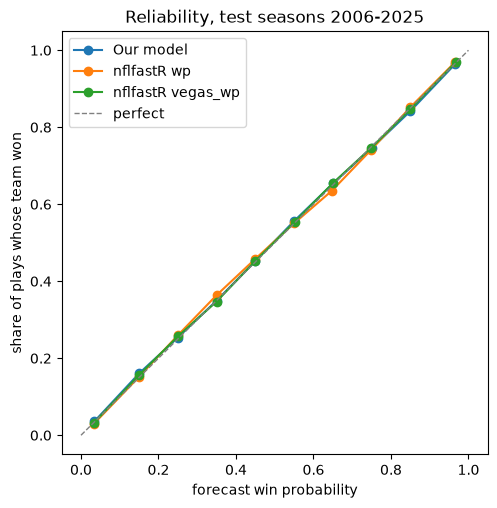

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for m, col in wr.METHODS.items():
    rel = pp.group_by(((pl.col(col) * 10).floor().clip(0, 9)).alias("bin")).agg(
        pl.col(col).mean().alias("predicted"), pl.col("posteam_wins").mean().alias("observed")
    ).sort("bin")
    ax.plot(rel["predicted"], rel["observed"], marker="o", label=wr.LABELS[m])
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1, label="perfect")
ax.set_xlabel("forecast win probability")
ax.set_ylabel("share of plays whose team won")
ax.set_title("Reliability, test seasons 2006-2025")
ax.legend()
plt.show()

## 5. Where it differs from nflfastR

Season by season: our log loss minus `vegas_wp`'s (below zero = ours was better), with a 95%
interval from resampling games. Remember `vegas_wp` was partly trained on these very seasons.

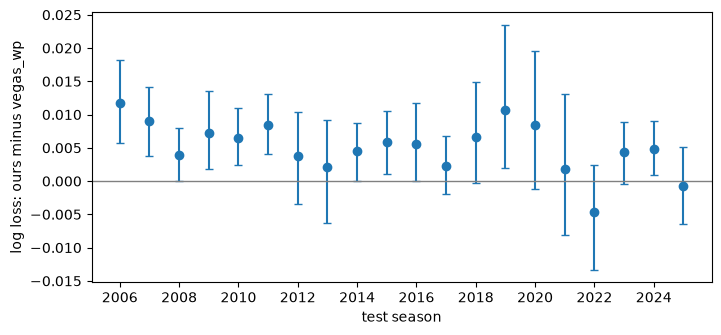

In [7]:
seasons = pl.DataFrame(wr.season_rows(pp), schema=wr.SCHEMA, orient="row").filter(
    pl.col("method") == "own - nflfastr_vegas_wp")
x = seasons["scope"].cast(pl.Int64).to_numpy()
v, lo, hi = (seasons[c].to_numpy() for c in ("value", "lo", "hi"))
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.errorbar(x, v, yerr=[v - lo, hi - v], fmt="o", capsize=3)
ax.axhline(0, color="grey", linewidth=1)
ax.set_xticks(x[::2])
ax.set_xlabel("test season")
ax.set_ylabel("log loss: ours minus vegas_wp")
plt.show()

In [8]:
gap = pp.with_columns((pl.col("prob") - pl.col("vegas_wp")).abs().alias("gap"))
print(f"median gap to vegas_wp: {gap['gap'].median():.3f}; "
      f"plays more than 10 points apart: {(gap['gap'] > 0.10).mean():.1%}")
gap.group_by("qtr").agg(pl.col("gap").mean().alias("mean gap"), pl.len().alias("plays")).sort("qtr")

median gap to vegas_wp: 0.016; plays more than 10 points apart: 1.7%


qtr,mean gap,plays
1,0.025126,170196
2,0.025647,204159
3,0.02231,170990
4,0.019838,203978
5,0.130758,4596
6,0.271218,4


## 6. Asking "what if?"

The grading steps will ask WP about situations that did not happen. Example, with the model
that scores 2025: tied, 5:00 left in the 4th quarter, 4th and 1 at the opponent's 40. If the
offense converts it has 1st and 10 around the 39; if it fails, the *opponent* has 1st and 10 at
its own 40 (60 yards from the end zone), so the offense's WP is 1 minus the opponent's.

In [9]:
model = wp.load_fold_model(2025)
base = {"season": 2025, "score_differential": 0, "game_seconds_remaining": 299,
        "half_seconds_remaining": 299, "half_number": 2, "down": 1, "ydstogo": 10,
        "posteam_timeouts_remaining": 3, "defteam_timeouts_remaining": 3,
        "receives_2h_kickoff": 0, "posteam_is_home": 1.0, "posteam_spread": 0.0}
convert = pl.DataFrame([{**base, "yardline_100": 39}])
fail = pl.DataFrame([{**base, "yardline_100": 60, "posteam_is_home": 0.0}])
print(f"WP if converted: {wp.wp(convert, model)[0]:.1%}; "
      f"if it fails: {1 - wp.wp(fail, model)[0]:.1%}")

WP if converted: 65.5%; if it fails: 42.4%


## Take-aways

- The full comparison (eras, 4th quarter, one-score games, first play of drives, per season)
  is in `reports/decisions/wp_backtest.md`.
- Ours clearly beats nflfastR's `wp` (which ignores the spread) and trails `vegas_wp` by a
  small margin. `vegas_wp` is partly in-sample on these seasons, so that gap is expected; it
  shrinks in 2023-2025, where nflfastR's own advantage should be smallest.
- The biggest disagreements are in overtime (the table above): nflfastR's two columns are equal
  there, and our model forecasts those plays better (report, "Overtime" slice).
- Nothing is in production yet: steps G3/G6 decide which fold scores live games.